# Progetto 2 — Regressione Multi-Target (dataset Linnerud)

Il dataset **Linnerud** presenta un problema di regressione **Multi-Target** (3 target: Weight, Waist, Pulse).
Obiettivo: addestrare e confrontare alcuni modelli di regressione, riducendo il problema da Multi-Target a Single-Target tramite **(1) PCA** e **(2) selezione manuale di un singolo target**.

## Consegna
1. **Data Exploration & Preprocessing** — caricamento + `describe()`; standardizzazione delle feature `X`
2. **Target Engineering** — due problemi Single-Target: (a) PCA sui target standardizzati, tieni PC1; (b) selezione manuale del target `Waist` standardizzato
3. **Addestramento & Valutazione** — Linear, Ridge (α=1.0), Lasso (α=0.1) su entrambi gli scenari, feature complete standardizzate; salvare MSE e R² per ogni combinazione
4. **Analisi & Visualizzazione** — PCA sulle feature (PC1, PC2); scatter con X=PC1 feature, Y=target PCA; tracciare le 3 rette di regressione riaddestrate sulla sola PC1, con R² nell'etichetta

## Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_linnerud
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

## 1a. Caricamento e analisi descrittiva (`describe()`)

In [2]:
linnerud = load_linnerud()
X = linnerud.data
y = linnerud.target

df_X = pd.DataFrame(X, columns=linnerud.feature_names)
df_y = pd.DataFrame(y, columns=linnerud.target_names)

print(df_X.describe())
print(df_y.describe())

           Chins      Situps      Jumps
count  20.000000   20.000000   20.00000
mean    9.450000  145.550000   70.30000
std     5.286278   62.566575   51.27747
min     1.000000   50.000000   25.00000
25%     4.750000  101.000000   39.50000
50%    11.500000  122.500000   54.00000
75%    13.250000  210.000000   85.25000
max    17.000000  251.000000  250.00000
           Weight      Waist      Pulse
count   20.000000  20.000000  20.000000
mean   178.600000  35.400000  56.100000
std     24.690505   3.201973   7.210373
min    138.000000  31.000000  46.000000
25%    160.750000  33.000000  51.500000
50%    176.000000  35.000000  55.000000
75%    191.500000  37.000000  60.500000
max    247.000000  46.000000  74.000000


## 1b. Standardizzazione delle feature X

In [3]:
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)


## 2a. Target Engineering — PCA sui target (tieni PC1)

In [4]:
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

pca_target = PCA(n_components=1)
y_pca = pca_target.fit_transform(y_scaled)


## 2b. Target Engineering — selezione manuale del target `Waist`

In [5]:
y_waist = y_scaled[:, 1]


## 3. Addestramento & Valutazione (Linear, Ridge, Lasso × 2 scenari)

In [6]:
modelli = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1)
}

scenari = {
    'PCA (composto)': y_pca.ravel(),
    'Waist (manuale)': y_waist
}

risultati = []
for nome_scenario, target in scenari.items():
    for nome_modello, modello in modelli.items():
        modello.fit(X_scaled, target)
        pred = modello.predict(X_scaled)
        mse = mean_squared_error(target, pred)
        r2 = r2_score(target, pred)
        risultati.append({
            'Scenario': nome_scenario,
            'Modello': nome_modello,
            'MSE': mse,
            'R2': r2
        })

risultati_df = pd.DataFrame(risultati)
print(risultati_df)


          Scenario Modello       MSE        R2
0   PCA (composto)  Linear  1.268880  0.396958
1   PCA (composto)   Ridge  1.275908  0.393618
2   PCA (composto)   Lasso  1.332376  0.366781
3  Waist (manuale)  Linear  0.452156  0.547844
4  Waist (manuale)   Ridge  0.456687  0.543313
5  Waist (manuale)   Lasso  0.515654  0.484346


## 4a. PCA sulle feature (PC1, PC2 per la visualizzazione 2D)

In [7]:
pca_feat = PCA(n_components=2)
X_pca = pca_feat.fit_transform(X_scaled)


## 4b. Scatter + rette di regressione sulla sola PC1 (con R² nell'etichetta)

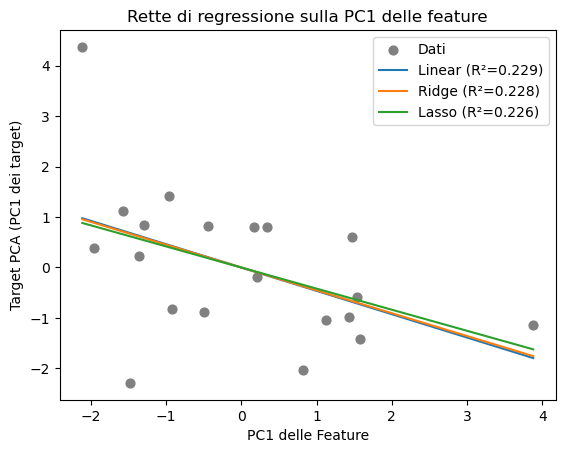

In [8]:
pc1_feat = X_pca[:, 0].reshape(-1, 1)   # 1 feature, in forma 2D per sklearn
target_pca = y_pca.ravel()               # target composto, 1D

# nuvola di punti
plt.scatter(X_pca[:, 0], target_pca, color='gray', s=40, label='Dati')

# valori X ordinati per disegnare rette lisce
x_line = np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 100).reshape(-1, 1)

modelli_1feat = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1)
}
for nome, modello in modelli_1feat.items():
    modello.fit(pc1_feat, target_pca)
    r2 = r2_score(target_pca, modello.predict(pc1_feat))
    plt.plot(x_line, modello.predict(x_line), label=f'{nome} (R²={r2:.3f})')

plt.xlabel('PC1 delle Feature')
plt.ylabel('Target PCA (PC1 dei target)')
plt.title('Rette di regressione sulla PC1 delle feature')
plt.legend()
plt.show()
